___
<img style="float: right; margin: 15px 15px 15px 15px;" src="https://www.velaninfo.com/rs/wp-content/uploads/2024/11/Data-Annotation-Labeling.jpg" width="300px" height="180px" />


# <font color= #bbc28d> **Object Detection in Urban Setting** </font>
#### <font color= #2E9AFE> `Final Project - Machine Learning`</font>
- <Strong> Sofía Maldonado, Diana Valdivia, Samantha Sánchez, Isabel Valladolid & Vivienne Toledo </Strong>
- <Strong> Fecha </Strong>: 01/12/2025.

___

<p style="text-align:right;"> Image retrieved from: https://www.velaninfo.com/rs/wp-content/uploads/2024/11/Data-Annotation-Labeling.jpg</p>

# <font color= #bbc28d> **Introduction** </font>

Urban environments present some of the most challenging scenarios for **computer vision systems**, especially in applications such as autonomous driving and advanced driver-assistance systems (ADAS). Vehicles operating in these contexts must be capable of perceiving their surroundings accurately and quickly, **identifying critical elements** such as cars, pedestrians, traffic signs, and other road objects in real time. To address this need, this project focuses on developing a **object recognition system** tailored for urban street video.

In this assignment, the entire perception pipeline is implemented within a Jupyter notebook using Python, OpenCV, and pretrained deep learning detectors from the YOLO family or other comparable high-performance models. The system is designed to **process recorded footage**, perform object detection at real-time speeds, and annotate the video with labels for key road elements. Additionally, the project evaluates the system’s performance by measuring accuracy, detection quality, and latency.

----

In [2]:
# === IMPORTS ===

# Generales
import numpy as np
import pandas as pd

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Paths & Data Loading
import json
import os
import cv2
import shutil

# Data Processing
import random
from tqdm import tqdm
from PIL import Image
from collections import defaultdict
from skmultilearn.model_selection import iterative_train_test_split
from collections import Counter

# Data Modeling
import torch
from ultralytics import YOLO
from transformers import pipeline

# <font color= #bbc28d> **Data Loading** </font>
For training our model, we considered three options. We ultimately selected the first one: using the **BDD100K dataset** from Berkeley to train our models. However, we did not use the entire dataset. Instead, we created a curated subset. To achieve this, we used only the **validation split** (approximately 10k images) and randomly selected **2,500 images** — using a fixed seed for reproducibility — to train our models.

The validation images and annotations can be downloaded from here: https://www.kaggle.com/datasets/marquis03/bdd100k?resource=download-directory&select=val 

Before diving into the process, let's establish the general aspects of the project:

In [2]:
 # ========== CONFIGURACIÓN GENERAL ==========

# Número total de imágenes que quieres tomar de BDD100K
num_images = 2500

# Porcentajes de división del dataset
train_ratio = 0.75
val_ratio = 0.15
test_ratio = 0.10

# Rutas de las imágenes
images_dir = r"C:\Users\Vivienne\Downloads\val\images"

# JSON de las anotaciones
labels_json = r"C:\Users\Vivienne\Downloads\val\annotations\bdd100k_labels_images_val.json"

# Carpeta final 
out_dir = r"dataset_yolo_balanced"
os.makedirs(out_dir, exist_ok=True)

## <font color= #66b0b0> • **Class Mapping** </font>
This section defines the list of classes that YOLO will detect in our project. The list yolo_classes contains the seven categories we want to recognize: cars, trucks, buses, pedestrians, cyclists, traffic lights, and traffic signs. Then, the dictionary bdd_to_yolo is used to map the original BDD100K class names to the numeric IDs required by YOLO.

In [3]:
# ========== MAPEO DE CLASES PARA YOLO ==========

# Lista de clases de Yolo
yolo_classes = [
    "car", "truck", "bus",
    "pedestrian", "cyclist",
    "traffic light", "traffic sign"
]

# Mapeo del nombre de categoría 
bdd_to_yolo = {
    "car": 0,
    "truck": 1,
    "bus": 2,
    "pedestrian": 3,
    "rider": 4,           # cyclist
    "traffic light": 5,
    "traffic sign": 6
}

## <font color= #66b0b0> • **Class Mapping** </font>
This section contains the helper functions used to load, process, and convert the BDD100K annotations into the YOLO format.

##### **`load_annotations()`**
This function reads the JSON file that contains all BDD100K labels. Each entry in the JSON includes the image name and a list of annotated objects. The function simply opens the file and returns its content as a Python dictionary.

##### **`yolo_bbox()`**
BDD100K bounding boxes use the format (x1, y1, x2, y2), where the coordinates represent the top-left and bottom-right corners of the box. YOLO requires a different format: the center of the box (xc, yc) and its width and height.
This function converts each BDD100K box to the normalized YOLO format.

##### **`process_labels()`**
This function processes the entire annotation JSON and builds a dictionary where each key is an image name and each value is a list of YOLO-formatted labels. It only keeps images that:

- Actually exist in the images folder,
- Contain at least one object,
- Have valid categories from our YOLO class list.

For every object, it checks if the category is allowed, converts the bounding box with yolo_bbox(), and saves it. Only images with valid annotations are included in the final output.

##### **`write_yolo_label()`**
This function creates a .txt file for each image in YOLO format.All values are normalized and written with six decimal places, which is the format expected by YOLO.

In [37]:
# ========== FUNCIONES AUXILIARES ==========

def load_annotations(json_path):
    """
    Carga el archivo JSON de anotaciones BDD100K.
    Cada elemento del JSON contiene:
        - name (nombre de la imagen)
        - labels (lista de objetos con su bbox)
    """
    print(f"→ Cargando labels de {json_path}...")
    with open(json_path, 'r') as f:
        return json.load(f)


def yolo_bbox(box, w, h):
    """
    Convierte una caja en formato BDD100K a formato YOLO.

    BDD100K usa:
        x1, y1 = esquina superior izquierda
        x2, y2 = esquina inferior derecha

    YOLO usa:
        xc, yc = centro (normalizado)
        bw, bh = ancho y alto (normalizados)
    """
    x1, y1, x2, y2 = box
    xc = ((x1 + x2) / 2) / w
    yc = ((y1 + y2) / 2) / h
    bw = (x2 - x1) / w
    bh = (y2 - y1) / h
    return xc, yc, bw, bh


def process_labels(ann_data):
    """
    Procesa el JSON de anotaciones completo y crea un diccionario:

        { "nombre_imagen.jpg": [(class_id, bbox), ...] }

    SOLO incluye imágenes que:
        ✓ existen físicamente en tu carpeta
        ✓ tienen al menos un objeto etiquetado
        ✓ contienen categorías válidas según tu lista YOLO
    """
    out = {}

    for item in ann_data:
        filename = item["name"]

        # Saltamos imágenes sin labels
        if "labels" not in item:
            continue

        # Usamos PIL para obtener el tamaño real de la imagen
        img_path = os.path.join(images_dir, filename)
        if not os.path.exists(img_path):
            continue  # el JSON tiene algunas imágenes que no existen

        img = Image.open(img_path)
        w, h = img.size  # dimensiones reales de la imagen

        file_labels = []

        # Revisar todos los objetos anotados en esta imagen
        for obj in item["labels"]:

            # Solo objetos con caja 2D válida
            if "box2d" not in obj:
                continue

            cat = obj["category"]

            # Si la categoría NO está en nuestra lista, se ignora
            if cat not in bdd_to_yolo:
                continue

            cls_id = bdd_to_yolo[cat]
            b = obj["box2d"]

            # Conversión a formato YOLO
            box_list = [b["x1"], b["y1"], b["x2"], b["y2"]]

            bbox = yolo_bbox(box_list, w, h)

            file_labels.append((cls_id, bbox))

        # Solo guardamos imágenes que tengan objetos válidos
        if file_labels:
            out[filename] = file_labels

    return out

def write_yolo_label(path, labels):
    """
    Crea un archivo .txt con las anotaciones en formato YOLO.
    Cada línea tiene:
        <class> <xc> <yc> <bw> <bh>
    """
    with open(path, "w") as f:
        for cls_id, (xc, yc, bw, bh) in labels:
            f.write(f"{cls_id} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}\n")

In [38]:
print("Cargando anotaciones del JSON...")
ann_data = load_annotations(labels_json)

print("Procesando y filtrando labels válidos...")
all_labels = process_labels(ann_data)

print(f"✔ Total imágenes con anotaciones válidas: {len(all_labels)}")

Cargando anotaciones del JSON...
→ Cargando labels de C:\Users\Vivienne\Downloads\val\annotations\bdd100k_labels_images_val.json...
Procesando y filtrando labels válidos...
✔ Total imágenes con anotaciones válidas: 9992


## <font color= #66b0b0> • **Dataset Creation** </font>

This block loads the annotations, filters the valid ones, and builds the final YOLO dataset.

**1. Load annotations**: We read the JSON file and extract all objects and bounding boxes. Only images that exist and contain valid categories are kept.

**2. Select 2,500 images**: From all valid images, we randomly choose 2500, a fixed seed is used so the selection is always the same.

**3. Train/Val/Test split**: The 2,500 images are split into:
- **Train:** 75%**
- **Val:** 15%**
- **Test:** 10%

**4. Create YOLO folder structure**: We create the standard YOLO directories with the images and annotations.

**5. Copy images and save labels**: For each image:
- The image is copied into the correct folder.
- A `.txt` file is created with its YOLO annotations.


In [41]:
# ======================================================================================
# ===================== MULTILABEL STRATIFIED TRAIN/VAL/TEST SPLIT =====================
# ======================================================================================

print("\nConstruyendo matriz multilabel para estratificación...")

# --- Create multilabel matrix for each image ---
images = list(all_labels.keys())     # image filenames
n_classes = len(yolo_classes)

multi_hot = []
for img in images:
    classes = {cls for cls, _ in all_labels[img]}
    row = [1 if c in classes else 0 for c in range(n_classes)]
    multi_hot.append(row)

X = np.array(images).reshape(-1, 1)          # shape (N,1) → required by library
y = np.array(multi_hot)                      # shape (N, n_classes)

print(f"Total imágenes con etiquetas válidas: {len(images)}")
print("Realizando división estratificada multilabel...")

# ---- First split: train vs (val+test) ----
X_train, y_train, X_temp, y_temp = iterative_train_test_split(
    X, y, test_size=(1 - train_ratio)
)

# ---- Second split: val vs test ----
remaining = val_ratio + test_ratio
val_test_ratio = test_ratio / remaining     # proportion of temp going to test

X_val, y_val, X_test, y_test = iterative_train_test_split(
    X_temp, y_temp, test_size=val_test_ratio
)

# Flatten back to Python lists
train_set = [x[0] for x in X_train]
val_set   = [x[0] for x in X_val]
test_set  = [x[0] for x in X_test]

# If user limits dataset size
if num_images < len(images):
    print(f"Reduciendo a {num_images} imágenes totales...")

    combined = train_set + val_set + test_set
    random.shuffle(combined)
    combined = combined[:num_images]

    # Recalculate splits based solely on ratios (NOT for stratification)
    n_train = int(num_images * train_ratio)
    n_val = int(num_images * val_ratio)

    train_set = combined[:n_train]
    val_set   = combined[n_train:n_train + n_val]
    test_set  = combined[n_train + n_val:]

print("\n✔ División estratificada multilabel completada:")
print(f"  Train: {len(train_set)} imágenes")
print(f"  Val:   {len(val_set)} imágenes")
print(f"  Test:  {len(test_set)} imágenes")

# Save final split structure
splits = {
    "train": train_set,
    "val": val_set,
    "test": test_set
}


Construyendo matriz multilabel para estratificación...
Total imágenes con etiquetas válidas: 9992
Realizando división estratificada multilabel...
Reduciendo a 2500 imágenes totales...

✔ División estratificada multilabel completada:
  Train: 1875 imágenes
  Val:   375 imágenes
  Test:  250 imágenes


Visualize classes:

In [40]:
def plot_class_distribution(splits, all_labels, class_names):
    """
    splits: dict {"train": [...], "val": [...], "test": [...]}
    all_labels: dict {image: [(class_id, bbox), ...]}
    class_names: list of class names
    """

    n_classes = len(class_names)
    split_names = splits.keys()
    
    # Count classes per split
    counts = {split: [0]*n_classes for split in split_names}
    
    for split, images in splits.items():
        for img in images:
            for cls_id, _ in all_labels[img]:
                counts[split][cls_id] += 1
    
    # Plot
    x = range(n_classes)
    width = 0.25

    plt.figure(figsize=(8,6))
    
    for i, split in enumerate(split_names):
        plt.bar([p + width*i for p in x], counts[split], width=width, label=split)
    
    plt.xticks([p + width for p in x], class_names, rotation=45)
    plt.ylabel("Number of objects")
    plt.title("Class distribution per split")
    plt.legend()
    plt.tight_layout()
    plt.show()

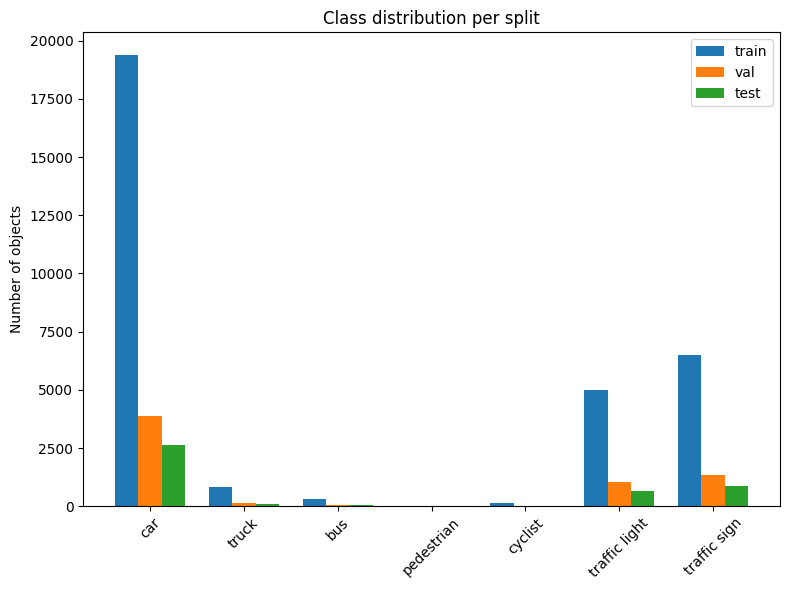

In [24]:
plot_class_distribution(splits, all_labels, yolo_classes)

## <font color= #66b0b0> • **YAML Creation** </font>

This section generates the `dataset.yaml` file required by YOLO. The YAML tells the model where the images and labels are located and what classes it should expect:
- The paths to the **train**, **val**, and **test** image folders.
- The number of classes (`nc`).
- The list of class names (`names`).

YOLO uses this file during training to correctly load the dataset and map the class IDs to their names.

In [42]:
folders = [
    "images/train", "images/val", "images/test",
    "labels/train", "labels/val", "labels/test"
]

for folder in folders:
    os.makedirs(os.path.join(out_dir, folder), exist_ok=True)

print("\nCopiando imágenes y escribiendo labels...")

for split_name, split_list in splits.items():
    img_dst = os.path.join(out_dir, "images", split_name)
    lbl_dst = os.path.join(out_dir, "labels", split_name)

    for img_name in split_list:
        src_img = os.path.join(images_dir, img_name)
        dst_img = os.path.join(img_dst, img_name)

        # Copy image
        shutil.copy2(src_img, dst_img)

        # Write YOLO label
        lbl_name = os.path.splitext(img_name)[0] + ".txt"
        dst_lbl = os.path.join(lbl_dst, lbl_name)
        write_yolo_label(dst_lbl, all_labels[img_name])

print("\n✔ Todas las imágenes y labels copiadas correctamente.")



Copiando imágenes y escribiendo labels...

✔ Todas las imágenes y labels copiadas correctamente.


In [47]:
# ========== CREAR UN YAML PARA YOLO ==========
yaml_path = os.path.join(out_dir, "dataset.yaml")

with open(yaml_path, "w") as f:
    f.write("train: images/train\n")
    f.write("val:   images/val\n")
    f.write("test:  images/test\n\n")
    f.write(f"nc: {len(yolo_classes)}\n")
    f.write(f"names: {yolo_classes}\n")

print(f"dataset.yaml generado en: {yaml_path}")

dataset.yaml generado en: dataset_yolo_balanced\dataset.yaml


# <font color= #bbc28d> **Modeling** </font>

YOLO (You Only Look Once) models are real-time object detection algorithms introduced a decade ago, which **frame object detection as regression problems rather than classification problems**. This means that it **spatially separates bounding boxes inside an image, and it associates a probability to each box corresponding to a class**, using a simple Convolutional Neural Network (CNN).

Thus, it specializes in object detection, which involves identifying and localizing objects within an image or video. YOLO models lead the competition in regards to object detection since the models are known to be: fast, accurate, universal and open-source. Throughout the years, multiple YOLO versions have been released, which improve performance upon the last one. In this project, we will be using YOLOV8 and YOLOV9.

In [4]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")
print(torch.__version__)

True
NVIDIA GeForce RTX 4050 Laptop GPU
2.5.1+cu121


## <font color= #66b0b0> • **YOLO v8 small** </font>

YOLOv8 was launched in 2023, which improved modularity and flexibility. It now allows further and easier customization and fine-tuning, lightweight versions which are more optimized, and support for custom datasets.

In this case, we will be loading YOLOv8 small due to performance concerns, with the following parameters:

- **Epochs:** 30
- **Image Size:** 512
- **Batches:** 8
- **Workers:** 2

In [ ]:
model = YOLO("yolov8s.pt")

model.train(
    data=r"dataset_yolo_balanced\dataset.yaml",
    epochs=30,
    imgsz=512,            # or 384 / 320
    batch=8,              # if you get OOM → try 6, 4, or 2
    device=0,
    workers=2,            # lower workers reduces VRAM spikes
    half=True,            # IMPORTANT: 6GB GPUs benefit from FP16
    cache=False,          # do NOT cache on small VRAM GPUs
    verbose=False
)

## <font color= #66b0b0> • **YOLO v9 small** </font>

YOLOv9 was launched a year later, in 2024. It now comes with Programmable Gradient Information (PGI), a new technique that optimizes gradient flow during training, which improves the model's ability to learn from complex data efficiently, and Generalized Efficient Layer Aggregation Network (GELAN), an architectural enhancement to improve feature learning and aggregation. 

Additionally, it addresses information loss in small models, preventing the model compression from affecting results. Thus, we will be loading YOLOv9 small, with the following parameters: 

- **Epochs:** 30
- **Image Size:** 512
- **Batches:** 8
- **Workers:** 2

In [ ]:
model = YOLO("yolov9s.pt")

model.train(
    data=r"dataset_yolo\dataset.yaml",
    epochs=30,
    imgsz=512,            # or 384 / 320
    batch=8,              # if you get OOM → try 6, 4, or 2
    device=0,
    workers=2,            # lower workers reduces VRAM spikes
    half=True,            # IMPORTANT: 6GB GPUs benefit from FP16
    cache=False,          # do NOT cache on small VRAM GPUs
    verbose=False
)

## <font color= #66b0b0> • **YOLOS w/o Tuning** </font>

YOLOS is a Vision Transformer (ViT) model, used in object detection. These families of models treat **images as sequences**, similar to how language models process text, **which allows them to capture global context and relationships between pixels effectively**.

In [10]:
yolos_detector = pipeline(
    task="object-detection",
    model="hustvl/yolos-base",
    dtype=torch.float16,
    device=0
)

# <font color= #bbc28d> **Results** </font>

## <font color= #66b0b0> • **YOLO v8 small** </font>

In [12]:
run_path ='runs/detect/train_30E_512SZ_V8s_balanced/results.csv' 

metrics = pd.read_csv(run_path)
metrics.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
25,26,1021.01,1.23794,0.70007,0.94025,0.62619,0.36538,0.38931,0.22229,1.34862,0.80153,0.99028,0.000159,0.000159,0.000159
26,27,1060.34,1.21894,0.68863,0.93351,0.52736,0.37744,0.38137,0.21639,1.34188,0.79649,0.98560,0.000129,0.000129,0.000129
27,28,1099.78,1.22303,0.68164,0.93603,0.51172,0.38696,0.39160,0.22461,1.33540,0.79859,0.98659,0.000099,0.000099,0.000099
28,29,1140.72,1.21210,0.67368,0.93424,0.59155,0.35916,0.40136,0.23158,1.33105,0.78777,0.98443,0.000069,0.000069,0.000069
29,30,1180.13,1.19360,0.65607,0.92813,0.57521,0.36497,0.39276,0.22782,1.32802,0.79178,0.98514,0.000039,0.000039,0.000039


## <font color= #66b0b0> • **YOLO v9 small** </font>

In [14]:
run_path ='runs/detect/train_30E_512SZ_V9/results.csv' 

metrics = pd.read_csv(run_path)
metrics.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
25,26,2486.17,1.24948,0.68748,0.98704,0.57152,0.36666,0.36618,0.21183,1.29787,0.75244,1.03210,0.000159,0.000159,0.000159
26,27,2587.31,1.24278,0.68202,0.98627,0.52074,0.34312,0.36287,0.21169,1.29237,0.75042,1.02542,0.000129,0.000129,0.000129
27,28,2684.82,1.22980,0.66628,0.97871,0.53546,0.37793,0.36797,0.21376,1.29186,0.74544,1.02694,0.000099,0.000099,0.000099
28,29,2794.12,1.22937,0.66096,0.97731,0.48927,0.37722,0.37153,0.21367,1.29265,0.74553,1.02540,0.000069,0.000069,0.000069
29,30,2895.21,1.21559,0.65153,0.97168,0.51042,0.38824,0.37257,0.21560,1.28357,0.74041,1.02542,0.000039,0.000039,0.000039


# <font color= #bbc28d> **Validation** </font>

For validating our models, we're going to select the one that performed the best, YOLOv8, as well as a pre-trained object identification model, YOLOS. Both of these models will predict videos taken by the team in urban settings.

Firstly, we establish the folders to store all the images:

In [ ]:
# Configuration: Select frames from video folder  
video_folder = "validation/videos"
frame_interval = 10

# Output folders for each model
yolov8_frames_folder = "validation/videoframes_yolov8"
yolos_frames_folder = "validation/videoframes_yolos" 
yolov8_videos_folder = "validation/labeled_videos_yolov8"
yolos_videos_folder = "validation/labeled_videos_yolos"

# Create all output directories
for folder in [yolov8_frames_folder, yolos_frames_folder, yolov8_videos_folder, yolos_videos_folder]:
    os.makedirs(folder, exist_ok=True)

And then, we extract the frames from the images using a frame interval. 

In [21]:
# Extract frames for videos
for video_file in os.listdir(video_folder):
    if video_file.endswith(".mp4"):
        video_path = os.path.join(video_folder, video_file)
        cap = cv2.VideoCapture(video_path)
        
        count = 0
        saved_count = 0
        
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            
            if count % frame_interval == 0:
                # Save frames for both models in their respective folders
                frame_filename = f"{os.path.splitext(video_file)[0]}_frame{saved_count}.jpg"
                
                # Save to YOLOv8 folder
                yolov8_frame_path = os.path.join(yolov8_frames_folder, frame_filename)
                cv2.imwrite(yolov8_frame_path, frame)
                
                # Save to YOLOS folder  
                yolos_frame_path = os.path.join(yolos_frames_folder, frame_filename)
                cv2.imwrite(yolos_frame_path, frame)
                
                saved_count += 1
            
            count += 1
        
        cap.release()
        print(f"Extracted {saved_count} frames from {video_file}")

Extracted 528 frames from video2.mp4


## <font color= #66b0b0> • **YOLO v8 small** </font>

YOLO v8 will be predicting every 10 frames:

In [22]:
# Load trained YOLO model
yolov8_model = YOLO(r"runs\detect\train_30E_512SZ_V8s_balanced\weights\best.pt")

# Process each video
for video_file in os.listdir(video_folder):
    if not video_file.endswith(".mp4"):
        continue
    
    video_path = os.path.join(video_folder, video_file)
    cap = cv2.VideoCapture(video_path)

    # Video properties
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    
    # Output video writer
    output_path = os.path.join(yolov8_videos_folder, f"yolov8_labeled_{video_file}")
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    frame_count = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Run YOLO inference on the frame
        results = yolov8_model(frame)
        
        # Draw predictions on the frame
        annotated_frame = results[0].plot()

        out.write(annotated_frame)
        frame_count += 1

    cap.release()
    out.release()
    print(f"YOLOv8: Processed {frame_count} frames for {video_file}")


0: 288x512 6 cars, 1 traffic sign, 54.2ms
Speed: 2.7ms preprocess, 54.2ms inference, 2.2ms postprocess per image at shape (1, 3, 288, 512)

0: 288x512 6 cars, 25.5ms
Speed: 2.0ms preprocess, 25.5ms inference, 1.9ms postprocess per image at shape (1, 3, 288, 512)

0: 288x512 7 cars, 25.4ms
Speed: 2.7ms preprocess, 25.4ms inference, 2.5ms postprocess per image at shape (1, 3, 288, 512)

0: 288x512 6 cars, 25.4ms
Speed: 2.6ms preprocess, 25.4ms inference, 1.8ms postprocess per image at shape (1, 3, 288, 512)

0: 288x512 7 cars, 25.4ms
Speed: 2.1ms preprocess, 25.4ms inference, 2.1ms postprocess per image at shape (1, 3, 288, 512)

0: 288x512 6 cars, 1 traffic sign, 25.4ms
Speed: 2.6ms preprocess, 25.4ms inference, 1.7ms postprocess per image at shape (1, 3, 288, 512)

0: 288x512 6 cars, 25.4ms
Speed: 2.1ms preprocess, 25.4ms inference, 1.8ms postprocess per image at shape (1, 3, 288, 512)

0: 288x512 8 cars, 1 truck, 25.3ms
Speed: 2.6ms preprocess, 25.3ms inference, 1.9ms postprocess per

## <font color= #66b0b0> • **YOLOS w/o Tuning** </font>

While YOLOS will be predicting every 1 frame, for smoothness reasons:

In [23]:
# Function to draw YOLOS detections on each frame
def draw_yolos_detections(frame, detections, class_colors, confidence_threshold=0.5):
    annotated_frame = frame.copy()
    
    for detection in detections:
        score = detection['score']
        if score < confidence_threshold:
            continue
            
        box = detection['box']
        # Store seen labels
        label = detection['label']
        
        # Get or create color for this class
        if label not in class_colors:
            # Generate random color for new class
            class_colors[label] = (
                np.random.randint(0, 255),
                np.random.randint(0, 255), 
                np.random.randint(0, 255)
            )
        
        color = class_colors[label]
        
        # Extract coordinates
        xmin = int(box['xmin'])
        ymin = int(box['ymin'])
        xmax = int(box['xmax'])
        ymax = int(box['ymax'])
        
        # Draw bounding box with class color 
        cv2.rectangle(annotated_frame, (xmin, ymin), (xmax, ymax), color, 2)  
        
        # Draw label background with class color
        label_text = f"{label}: {score:.2f}"
        label_size = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)[0]
        
        # Draw filled rectangle for label background
        cv2.rectangle(annotated_frame, 
                     (xmin, ymin - label_size[1] - 10), 
                     (xmin + label_size[0], ymin), 
                     color, -1)
        
        # Draw label text with white color for contrast
        cv2.putText(annotated_frame, label_text, (xmin, ymin - 5),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
    
    return annotated_frame

# Process videos with YOLOS
for video_file in os.listdir(video_folder):
    if not video_file.endswith(".mp4"):
        continue
    
    video_path = os.path.join(video_folder, video_file)
    cap = cv2.VideoCapture(video_path)

    # Video properties
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    
    # Output video writer
    output_path = os.path.join(yolos_videos_folder, f"yolos_labeled_{video_file}")
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    # Track colors for classes in this video
    class_colors = {}
    frame_count = 0
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Convert BGR to RGB for YOLOS
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        pil_image = Image.fromarray(rgb_frame)
        
        # Run YOLOS inference on EVERY frame
        detections = yolos_detector(pil_image)
        
        # Draw detections on the frame with class-based colors
        annotated_frame = draw_yolos_detections(frame, detections, class_colors)
        
        out.write(annotated_frame)
        frame_count += 1
        
        # Print progress every 30 frames
        if frame_count % 30 == 0:
            print(f"YOLOS: Processed {frame_count} frames for {video_file}")

    cap.release()
    out.release()

YOLOS: Processed 30 frames for video2.mp4
YOLOS: Processed 60 frames for video2.mp4
YOLOS: Processed 90 frames for video2.mp4
YOLOS: Processed 120 frames for video2.mp4
YOLOS: Processed 150 frames for video2.mp4
YOLOS: Processed 180 frames for video2.mp4
YOLOS: Processed 210 frames for video2.mp4
YOLOS: Processed 240 frames for video2.mp4
YOLOS: Processed 270 frames for video2.mp4
YOLOS: Processed 300 frames for video2.mp4
YOLOS: Processed 330 frames for video2.mp4
YOLOS: Processed 360 frames for video2.mp4
YOLOS: Processed 390 frames for video2.mp4
YOLOS: Processed 420 frames for video2.mp4
YOLOS: Processed 450 frames for video2.mp4
YOLOS: Processed 480 frames for video2.mp4
YOLOS: Processed 510 frames for video2.mp4
YOLOS: Processed 540 frames for video2.mp4
YOLOS: Processed 570 frames for video2.mp4
YOLOS: Processed 600 frames for video2.mp4
YOLOS: Processed 630 frames for video2.mp4
YOLOS: Processed 660 frames for video2.mp4
YOLOS: Processed 690 frames for video2.mp4
YOLOS: Process

# <font color= #bbc28d> **Conclusions** </font>

As seen in the labeled videos obtained by both models, YOLOS far outperforms the YOLOv8 model with fine tuning. This may be caused for a variety of reasons:

- YOLOv8 is a CNN that has a limited perception field, while YOLOS is a transformer with integrated attention.

- **YOLOS is better at generalizing and observing the whole picture**.

- YOLOv8 was pretrained on smaller data (COCO), while YOLOS has been pretrained on large datasets (ImageNet)

While running YOLOv8 small and YOLOv9 small with finetuning, we realized how costly these kinds of models are, since they rely on big training timeframes, they're GPU/CPU memory costly and they need big data samples. Thus, `a pretrained model like YOLOS is an excellent option to achieve great results in these kinds of tasks, especially when computational power is limited`.